# Project 1: Logistic Regression and Feed-Forward Neural Network

**Course:** Deep Learning and Natural Language Processing (PhDAI-831-A01)  
**Program:** Ph.D. in Artificial Intelligence  
**University:** University of the Cumberlands  
**Student:** Alok Dubey  

## Project Objective

This project applies logistic regression and a feed-forward neural network to sentiment classification using the IMDb movie review dataset.

Each movie review is represented using six sentiment features:

1. Count of positive lexicon words
2. Count of negative lexicon words
3. Presence of the word "no"
4. Count of first- and second-person pronouns
5. Presence of an exclamation mark (!)
6. Natural logarithm of the document word count

The models will learn from labeled IMDb reviews and determine parameters that can be used to classify previously unseen reviews as positive or negative.

In [1]:
# Core libraries
from pathlib import Path
import math
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# PyTorch
import torch
import torch.nn as nn

# Reproducibility
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

print("Python version:", sys.version.split()[0])
print("NumPy version:", np.__version__)
print("PyTorch version:", torch.__version__)
print("Project setup successful.")

Python version: 3.11.9
NumPy version: 1.26.4
PyTorch version: 2.10.0+cpu
Project setup successful.


## 1. Dataset

This project uses the Stanford Large Movie Review Dataset (IMDb), which contains labeled movie reviews for binary sentiment classification.

The dataset contains:

- 25,000 training reviews
- 25,000 testing reviews
- Positive sentiment label = 1
- Negative sentiment label = 0

The same dataset used previously for text-classification experiments is reused here. Rather than representing each document with a full bag-of-words vocabulary, this project converts each review into six manually engineered sentiment features.

In [2]:
# Path to the existing IMDb dataset
DATASET_PATH = Path(
    r"C:\Users\dubey\Documents\UC_GitLab"
    r"\Deep_Learning_NLP_Surdeanu"
    r"\Chapter_04_Text_Classification"
    r"\data"
    r"\aclImdb"
)

print("Dataset path:", DATASET_PATH)
print("Dataset exists:", DATASET_PATH.exists())

# Expected folders
for split in ["train", "test"]:
    for sentiment in ["pos", "neg"]:
        folder = DATASET_PATH / split / sentiment
        count = len(list(folder.glob("*.txt")))

        print(f"{split:5s} {sentiment}: {count:,} reviews")

Dataset path: C:\Users\dubey\Documents\UC_GitLab\Deep_Learning_NLP_Surdeanu\Chapter_04_Text_Classification\data\aclImdb
Dataset exists: True
train pos: 12,500 reviews
train neg: 12,500 reviews
test  pos: 12,500 reviews
test  neg: 12,500 reviews


## 2. Loading the IMDb Reviews

Each IMDb review is stored as a separate text file. Reviews located in the `pos` directories are assigned the label 1, while reviews in the `neg` directories are assigned the label 0.

The training and testing sets are loaded separately so that the models are trained only on the training data and evaluated on previously unseen testing data.

In [3]:
def load_imdb_split(dataset_path, split):
    """
    Load positive and negative IMDb reviews for a given split.

    Parameters
    ----------
    dataset_path : Path
        Root path of the aclImdb dataset.
    split : str
        Either 'train' or 'test'.

    Returns
    -------
    DataFrame
        Columns:
        - text  : review text
        - label : 1 for positive, 0 for negative
    """

    records = []

    for sentiment, label in [("pos", 1), ("neg", 0)]:
        folder = dataset_path / split / sentiment

        for file_path in folder.glob("*.txt"):
            text = file_path.read_text(
                encoding="utf-8",
                errors="ignore"
            )

            records.append({
                "text": text,
                "label": label
            })

    return pd.DataFrame(records)


train_df = load_imdb_split(DATASET_PATH, "train")
test_df = load_imdb_split(DATASET_PATH, "test")

print("Training set shape:", train_df.shape)
print("Testing set shape :", test_df.shape)

print("\nTraining labels:")
print(train_df["label"].value_counts().sort_index())

print("\nTesting labels:")
print(test_df["label"].value_counts().sort_index())

Training set shape: (25000, 2)
Testing set shape : (25000, 2)

Training labels:
label
0    12500
1    12500
Name: count, dtype: int64

Testing labels:
label
0    12500
1    12500
Name: count, dtype: int64


## 3. Sentiment Feature Engineering

Each movie review is transformed into six numerical sentiment features specified by the project requirements.

To identify positive and negative sentiment words, the implementation uses the NLTK Opinion Lexicon, which provides established lists of positive and negative English words. Using a predefined lexicon makes the feature extraction process reproducible and avoids manually assigning sentiment to words.

In [4]:
# Install/import NLTK if needed
try:
    import nltk
except ImportError:
    %pip install nltk -q
    import nltk

from nltk.corpus import opinion_lexicon

# Download the opinion lexicon if it is not already available
try:
    positive_words = set(opinion_lexicon.positive())
    negative_words = set(opinion_lexicon.negative())
except LookupError:
    nltk.download("opinion_lexicon")
    positive_words = set(opinion_lexicon.positive())
    negative_words = set(opinion_lexicon.negative())

print(f"Positive lexicon words: {len(positive_words):,}")
print(f"Negative lexicon words: {len(negative_words):,}")

[nltk_data] Downloading package opinion_lexicon to
[nltk_data]     C:\Users\dubey\AppData\Roaming\nltk_data...


Positive lexicon words: 2,006
Negative lexicon words: 4,783


[nltk_data]   Unzipping corpora\opinion_lexicon.zip.


### Six Sentiment Features

For each review, the following feature vector is constructed:

\[
\mathbf{x} =
[x_1,x_2,x_3,x_4,x_5,x_6]
\]

where:

- \(x_1\): count of positive lexicon words
- \(x_2\): count of negative lexicon words
- \(x_3\): indicator for whether the word "no" appears
- \(x_4\): count of first- and second-person pronouns
- \(x_5\): indicator for whether an exclamation mark appears
- \(x_6\): natural logarithm of the document word count

The logarithm is used for document length because review lengths can vary substantially. Taking the logarithm reduces the effect of extremely long documents.

In [6]:
# First- and second-person pronouns
PRONOUNS = {
    "i", "me", "my", "mine", "myself",
    "we", "us", "our", "ours", "ourselves",
    "you", "your", "yours", "yourself", "yourselves"
}

# Simple tokenizer: extract alphabetic words and apostrophes
TOKEN_PATTERN = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")


def extract_sentiment_features(text):
    """
    Convert one document into the six sentiment features required
    by the project.
    """

    # Convert text to lowercase and tokenize
    tokens = TOKEN_PATTERN.findall(text.lower())

    # Feature 1: positive lexicon word count
    positive_count = sum(
        token in positive_words
        for token in tokens
    )

    # Feature 2: negative lexicon word count
    negative_count = sum(
        token in negative_words
        for token in tokens
    )

    # Feature 3: whether "no" appears
    contains_no = int("no" in tokens)

    # Feature 4: first- and second-person pronoun count
    pronoun_count = sum(
        token in PRONOUNS
        for token in tokens
    )

    # Feature 5: whether an exclamation mark appears
    contains_exclamation = int("!" in text)

    # Feature 6: log of document word count
    word_count = max(len(tokens), 1)
    log_word_count = math.log(word_count)

    return [
        positive_count,
        negative_count,
        contains_no,
        pronoun_count,
        contains_exclamation,
        log_word_count,
    ]

In [7]:
sample_text = """
I absolutely loved this wonderful movie!
You should definitely watch it.
There was no boring moment and I really enjoyed it.
"""

sample_features = extract_sentiment_features(sample_text)

feature_names = [
    "positive_count",
    "negative_count",
    "contains_no",
    "pronoun_count",
    "contains_exclamation",
    "log_word_count",
]

for name, value in zip(feature_names, sample_features):
    print(f"{name:22s}: {value}")

positive_count        : 3
negative_count        : 1
contains_no           : 1
pronoun_count         : 3
contains_exclamation  : 1
log_word_count        : 3.044522437723423


In [8]:
FEATURE_NAMES = [
    "positive_count",
    "negative_count",
    "contains_no",
    "pronoun_count",
    "contains_exclamation",
    "log_word_count",
]


def build_feature_dataframe(df):
    """Extract the six sentiment features from every document."""

    feature_matrix = np.array(
        [extract_sentiment_features(text) for text in df["text"]],
        dtype=np.float64
    )

    features_df = pd.DataFrame(
        feature_matrix,
        columns=FEATURE_NAMES
    )

    features_df["label"] = df["label"].to_numpy()

    return features_df


print("Extracting training features...")
train_features_df = build_feature_dataframe(train_df)

print("Extracting testing features...")
test_features_df = build_feature_dataframe(test_df)

print("Feature extraction complete.")

print("\nTraining feature shape:", train_features_df.shape)
print("Testing feature shape :", test_features_df.shape)

train_features_df.head()

Extracting training features...
Extracting testing features...
Feature extraction complete.

Training feature shape: (25000, 7)
Testing feature shape : (25000, 7)


,positive_count,negative_count,contains_no,pronoun_count,contains_exclamation,log_word_count,label
0,5.0,5.0,0.0,9.0,1.0,4.919981,1
1,17.0,15.0,0.0,5.0,0.0,6.070738,1
2,9.0,7.0,0.0,2.0,0.0,5.003946,1
3,8.0,6.0,0.0,3.0,0.0,4.820282,1
4,6.0,2.0,0.0,0.0,0.0,4.795791,1


In [9]:
train_features_df.groupby("label")[FEATURE_NAMES].mean().round(3)

,positive_count,negative_count,contains_no,pronoun_count,contains_exclamation,log_word_count
label,,,,,,
0,8.412,11.473,0.399,6.386,0.353,5.252
1,12.045,7.840,0.258,6.015,0.334,5.248


## 4. Logistic Regression Model

For each review, the six engineered sentiment features form an input vector:

\[
\mathbf{x} =
[x_1,x_2,x_3,x_4,x_5,x_6]^T
\]

The logistic regression model first computes a weighted linear combination:

\[
z = \mathbf{w}^T\mathbf{x} + b
\]

where:

- \(\mathbf{x}\) is the six-dimensional feature vector.
- \(\mathbf{w}=[w_1,w_2,w_3,w_4,w_5,w_6]^T\) contains the model weights.
- \(b\) is the bias.
- \(z\) is the linear score produced by the model.

The score is converted into the probability of positive sentiment using the sigmoid function:

\[
\hat{y} = \sigma(z) = \frac{1}{1+e^{-z}}
\]

where \(\hat{y}\) represents the predicted probability that the review belongs to the positive class.

A probability threshold of 0.5 is used for classification:

\[
\text{class} =
\begin{cases}
1, & \hat{y} \geq 0.5\\
0, & \hat{y} < 0.5
\end{cases}
\]

### Loss Function

The model parameters are learned by minimizing binary cross-entropy loss:

\[
L =
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
\]

where:

- \(N\) is the number of training examples.
- \(y_i\) is the actual class label.
- \(\hat{y}_i\) is the predicted probability.

### Gradient Descent

The gradients of the loss with respect to the weights and bias are:

\[
\frac{\partial L}{\partial \mathbf{w}}
=
\frac{1}{N}X^T(\hat{\mathbf{y}}-\mathbf{y})
\]

and

\[
\frac{\partial L}{\partial b}
=
\frac{1}{N}
\sum_{i=1}^{N}
(\hat{y}_i-y_i)
\]

The parameters are repeatedly updated using gradient descent:

\[
\mathbf{w}
\leftarrow
\mathbf{w}
-
\eta
\frac{\partial L}{\partial \mathbf{w}}
\]

\[
b
\leftarrow
b
-
\eta
\frac{\partial L}{\partial b}
\]

where \(\eta\) is the learning rate.

Because binary logistic regression with cross-entropy loss is a convex optimization problem, gradient-based optimization can converge to the global optimum when an appropriate learning rate and sufficient training iterations are used.

In [10]:
# Separate features and labels
X_train_raw = train_features_df[FEATURE_NAMES].to_numpy(dtype=np.float64)
y_train = train_features_df["label"].to_numpy(dtype=np.float64)

X_test_raw = test_features_df[FEATURE_NAMES].to_numpy(dtype=np.float64)
y_test = test_features_df["label"].to_numpy(dtype=np.float64)

# Standardize using TRAINING data only
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

print("\nTraining feature means after standardization:")
print(np.round(X_train.mean(axis=0), 4))

print("\nTraining feature standard deviations:")
print(np.round(X_train.std(axis=0), 4))

X_train shape: (25000, 6)
y_train shape: (25000,)
X_test shape : (25000, 6)
y_test shape : (25000,)

Training feature means after standardization:
[-0.  0.  0. -0.  0. -0.]

Training feature standard deviations:
[1. 1. 1. 1. 1. 1.]


### Logistic Regression Implementation from Scratch

The following implementation directly applies the sigmoid function, binary cross-entropy loss, and gradient-descent equations described above. The weights and bias begin at zero and are repeatedly updated in the direction that reduces prediction error.

In [11]:
def sigmoid(z):
    """Numerically stable sigmoid function."""
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


def binary_cross_entropy(y_true, y_prob):
    """Calculate binary cross-entropy loss."""
    eps = 1e-12
    y_prob = np.clip(y_prob, eps, 1 - eps)

    return -np.mean(
        y_true * np.log(y_prob)
        + (1 - y_true) * np.log(1 - y_prob)
    )


def train_logistic_regression(
    X,
    y,
    learning_rate=0.05,
    epochs=3000
):
    """
    Train binary logistic regression using batch gradient descent.
    """

    n_samples, n_features = X.shape

    # Initialize parameters
    weights = np.zeros(n_features, dtype=np.float64)
    bias = 0.0

    loss_history = []

    for epoch in range(epochs):

        # Forward propagation
        z = X @ weights + bias
        probabilities = sigmoid(z)

        # Compute loss
        loss = binary_cross_entropy(y, probabilities)
        loss_history.append(loss)

        # Gradients
        error = probabilities - y

        dw = (X.T @ error) / n_samples
        db = np.mean(error)

        # Gradient descent update
        weights -= learning_rate * dw
        bias -= learning_rate * db

        if (epoch + 1) % 500 == 0:
            print(
                f"Epoch {epoch + 1:4d} | "
                f"Loss: {loss:.6f}"
            )

    return weights, bias, loss_history

In [12]:
logreg_weights_scaled, logreg_bias_scaled, logreg_loss_history = (
    train_logistic_regression(
        X_train,
        y_train,
        learning_rate=0.05,
        epochs=3000
    )
)

Epoch  500 | Loss: 0.554676
Epoch 1000 | Loss: 0.547852
Epoch 1500 | Loss: 0.546947
Epoch 2000 | Loss: 0.546801
Epoch 2500 | Loss: 0.546775
Epoch 3000 | Loss: 0.546771


In [13]:
print("\nLearned Logistic Regression Parameters")
print("-" * 55)

for name, weight in zip(FEATURE_NAMES, logreg_weights_scaled):
    print(f"{name:22s}: {weight: .6f}")

print(f"{'bias':22s}: {logreg_bias_scaled: .6f}")


Learned Logistic Regression Parameters
-------------------------------------------------------
positive_count        :  1.657172
negative_count        : -1.460008
contains_no           : -0.285815
pronoun_count         : -0.159205
contains_exclamation  : -0.021621
log_word_count        :  0.026307
bias                  :  0.011465


In [14]:
# Convert standardized-model coefficients back to original feature scale
logreg_weights_raw = logreg_weights_scaled / scaler.scale_

logreg_bias_raw = (
    logreg_bias_scaled
    - np.sum(
        logreg_weights_scaled
        * scaler.mean_
        / scaler.scale_
    )
)

print("\nLogistic Regression Parameters on Original Feature Scale")
print("-" * 65)

for name, weight in zip(FEATURE_NAMES, logreg_weights_raw):
    print(f"{name:22s}: {weight: .6f}")

print(f"{'bias':22s}: {logreg_bias_raw: .6f}")


Logistic Regression Parameters on Original Feature Scale
-----------------------------------------------------------------
positive_count        :  0.205613
negative_count        : -0.169755
contains_no           : -0.608538
pronoun_count         : -0.027845
contains_exclamation  : -0.045519
log_word_count        :  0.040702
bias                  : -0.277874


In [15]:
# Predict probabilities
test_probabilities = sigmoid(
    X_test @ logreg_weights_scaled
    + logreg_bias_scaled
)

# Convert probabilities to class predictions
test_predictions = (
    test_probabilities >= 0.5
).astype(int)

# Evaluation metrics
logreg_accuracy = accuracy_score(
    y_test,
    test_predictions
)

logreg_precision = precision_score(
    y_test,
    test_predictions
)

logreg_recall = recall_score(
    y_test,
    test_predictions
)

logreg_f1 = f1_score(
    y_test,
    test_predictions
)

print("Logistic Regression Test Results")
print("-" * 40)
print(f"Accuracy : {logreg_accuracy:.4f}")
print(f"Precision: {logreg_precision:.4f}")
print(f"Recall   : {logreg_recall:.4f}")
print(f"F1 Score : {logreg_f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_predictions))

Logistic Regression Test Results
----------------------------------------
Accuracy : 0.7386
Precision: 0.7397
Recall   : 0.7361
F1 Score : 0.7379

Confusion Matrix:
[[9263 3237]
 [3299 9201]]


## 5. Feed-Forward Neural Network

Logistic regression learns a linear decision boundary between positive and negative sentiment. A feed-forward neural network extends this idea by introducing hidden layers and nonlinear activation functions.

The neural network used in this project has the following architecture:

\[
6 \rightarrow 8 \rightarrow 4 \rightarrow 1
\]

where:

- The input layer contains the six sentiment features.
- The first hidden layer contains 8 neurons.
- The second hidden layer contains 4 neurons.
- ReLU activation is applied after each hidden layer.
- The output layer contains one neuron representing binary sentiment classification.

For the first hidden layer:

\[
\mathbf{h}_1 =
\text{ReLU}(W_1\mathbf{x}+\mathbf{b}_1)
\]

For the second hidden layer:

\[
\mathbf{h}_2 =
\text{ReLU}(W_2\mathbf{h}_1+\mathbf{b}_2)
\]

The output score is:

\[
z =
W_3\mathbf{h}_2+b_3
\]

and the predicted probability is:

\[
\hat{y}=\sigma(z)
\]

During training, binary cross-entropy loss measures the difference between the predicted probability and the true sentiment label. Backpropagation calculates the gradients of the loss with respect to the network parameters, and the optimizer updates the weights to reduce the loss.

In [16]:
from torch.utils.data import TensorDataset, DataLoader

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.reshape(-1, 1),
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test.reshape(-1, 1),
    dtype=torch.float32
)

# Create training dataset
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

# Mini-batch loader
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

print("Training tensor:", X_train_tensor.shape)
print("Training labels:", y_train_tensor.shape)
print("Testing tensor :", X_test_tensor.shape)
print("Training batches:", len(train_loader))

Training tensor: torch.Size([25000, 6])
Training labels: torch.Size([25000, 1])
Testing tensor : torch.Size([25000, 6])
Training batches: 391


In [17]:
class SentimentFFNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(6, 8),
            nn.ReLU(),

            nn.Linear(8, 4),
            nn.ReLU(),

            nn.Linear(4, 1)
        )

    def forward(self, x):
        return self.network(x)


# Reproducibility
torch.manual_seed(SEED)

model = SentimentFFNN()

print(model)

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

print("\nTotal trainable parameters:", total_parameters)

SentimentFFNN(
  (network): Sequential(
    (0): Linear(in_features=6, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=1, bias=True)
  )
)

Total trainable parameters: 97


In [18]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

NUM_EPOCHS = 50

ffnn_loss_history = []

In [19]:
for epoch in range(NUM_EPOCHS):

    model.train()

    running_loss = 0.0

    for X_batch, y_batch in train_loader:

        # 1. Clear old gradients
        optimizer.zero_grad()

        # 2. Forward propagation
        logits = model(X_batch)

        # 3. Calculate loss
        loss = criterion(logits, y_batch)

        # 4. Backpropagation
        loss.backward()

        # 5. Update weights and biases
        optimizer.step()

        running_loss += (
            loss.item() * X_batch.size(0)
        )

    epoch_loss = running_loss / len(train_dataset)

    ffnn_loss_history.append(epoch_loss)

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch + 1:2d}/{NUM_EPOCHS} | "
            f"Loss: {epoch_loss:.6f}"
        )

Epoch  5/50 | Loss: 0.520821
Epoch 10/50 | Loss: 0.516043
Epoch 15/50 | Loss: 0.515079
Epoch 20/50 | Loss: 0.514796
Epoch 25/50 | Loss: 0.513831
Epoch 30/50 | Loss: 0.513669
Epoch 35/50 | Loss: 0.513560
Epoch 40/50 | Loss: 0.513424
Epoch 45/50 | Loss: 0.513284
Epoch 50/50 | Loss: 0.513229


In [20]:
model.eval()

with torch.no_grad():

    test_logits = model(X_test_tensor)

    test_probabilities_ffnn = torch.sigmoid(
        test_logits
    )

    test_predictions_ffnn = (
        test_probabilities_ffnn >= 0.5
    ).int().numpy().flatten()


ffnn_accuracy = accuracy_score(
    y_test,
    test_predictions_ffnn
)

ffnn_precision = precision_score(
    y_test,
    test_predictions_ffnn
)

ffnn_recall = recall_score(
    y_test,
    test_predictions_ffnn
)

ffnn_f1 = f1_score(
    y_test,
    test_predictions_ffnn
)


print("Feed-Forward Neural Network Test Results")
print("-" * 45)

print(f"Accuracy : {ffnn_accuracy:.4f}")
print(f"Precision: {ffnn_precision:.4f}")
print(f"Recall   : {ffnn_recall:.4f}")
print(f"F1 Score : {ffnn_f1:.4f}")

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        test_predictions_ffnn
    )
)

Feed-Forward Neural Network Test Results
---------------------------------------------
Accuracy : 0.7419
Precision: 0.7539
Recall   : 0.7182
F1 Score : 0.7356

Confusion Matrix:
[[9570 2930]
 [3523 8977]]


In [21]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Feed-Forward Neural Network"
    ],

    "Accuracy": [
        logreg_accuracy,
        ffnn_accuracy
    ],

    "Precision": [
        logreg_precision,
        ffnn_precision
    ],

    "Recall": [
        logreg_recall,
        ffnn_recall
    ],

    "F1 Score": [
        logreg_f1,
        ffnn_f1
    ]
})

comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7386,0.7397,0.7361,0.7379
1,Feed-Forward Neural Network,0.7419,0.7539,0.7182,0.7356


## 6. Concrete Example of Learning During Training

To demonstrate how the feed-forward neural network learns, one training review is passed through a newly initialized network.

The network first produces a probability based on its initial random weights. Binary cross-entropy measures the error between this probability and the actual sentiment label.

Backpropagation then computes the gradients of this loss with respect to the network parameters. One gradient-descent update changes the weights and biases. When the same example is passed through the network again, its probability should move toward the correct class and its loss should decrease.

This demonstrates the basic learning process used repeatedly during full network training.

In [22]:
# Re-create a fresh network only for demonstrating one learning step
torch.manual_seed(SEED)

demo_model = SentimentFFNN()

demo_criterion = nn.BCEWithLogitsLoss()

demo_optimizer = torch.optim.SGD(
    demo_model.parameters(),
    lr=0.05
)

# Use one actual IMDb training example
x_demo = X_train_tensor[0:1]
y_demo = y_train_tensor[0:1]

# ---------------------------------------------------------
# BEFORE the training update
# ---------------------------------------------------------

with torch.no_grad():
    logits_before = demo_model(x_demo)
    probability_before = torch.sigmoid(logits_before)
    loss_before = demo_criterion(
        logits_before,
        y_demo
    )

output_bias_before = (
    demo_model.network[4]
    .bias.detach()
    .item()
)

# ---------------------------------------------------------
# ONE training step
# ---------------------------------------------------------

demo_optimizer.zero_grad()

logits = demo_model(x_demo)

loss = demo_criterion(
    logits,
    y_demo
)

loss.backward()

demo_optimizer.step()

# ---------------------------------------------------------
# AFTER the training update
# ---------------------------------------------------------

with torch.no_grad():
    logits_after = demo_model(x_demo)
    probability_after = torch.sigmoid(logits_after)
    loss_after = demo_criterion(
        logits_after,
        y_demo
    )

output_bias_after = (
    demo_model.network[4]
    .bias.detach()
    .item()
)

# Results
print("Concrete FFNN Learning Example")
print("-" * 45)

print(f"Actual label             : {int(y_demo.item())}")
print(f"Probability before update: {probability_before.item():.6f}")
print(f"Loss before update       : {loss_before.item():.6f}")

print()

print(f"Probability after update : {probability_after.item():.6f}")
print(f"Loss after update        : {loss_after.item():.6f}")

print()

print(f"Output bias before       : {output_bias_before:.6f}")
print(f"Output bias after        : {output_bias_after:.6f}")
print(
    f"Bias change              : "
    f"{output_bias_after - output_bias_before:.6f}"
)

Concrete FFNN Learning Example
---------------------------------------------
Actual label             : 1
Probability before update: 0.615680
Loss before update       : 0.485028

Probability after update : 0.621496
Loss after update        : 0.475625

Output bias before       : 0.457831
Output bias after        : 0.477047
Bias change              : 0.019216


## 7. Classification of a New Input

After training, the models can classify previously unseen text.

A new review is first converted into the same six sentiment features used during training. The features are standardized using the training-set scaler and then passed to the trained logistic regression model and feed-forward neural network.

A predicted probability greater than or equal to 0.5 is classified as positive sentiment; otherwise, the review is classified as negative sentiment.

In [23]:
new_review = """
I loved this movie! The story was wonderful and the performances
were excellent. I really enjoyed watching it and I would definitely
recommend it to you.
"""

print("New Review:")
print(new_review)

New Review:

I loved this movie! The story was wonderful and the performances
were excellent. I really enjoyed watching it and I would definitely
recommend it to you.



In [24]:
# Extract the six required sentiment features
new_features_raw = np.array(
    [extract_sentiment_features(new_review)],
    dtype=np.float64
)

print("Extracted Features")
print("-" * 45)

for name, value in zip(
    FEATURE_NAMES,
    new_features_raw[0]
):
    print(f"{name:22s}: {value:.4f}")

Extracted Features
---------------------------------------------
positive_count        : 5.0000
negative_count        : 0.0000
contains_no           : 0.0000
pronoun_count         : 4.0000
contains_exclamation  : 1.0000
log_word_count        : 3.2581


In [25]:
# Apply the same standardization learned from training data
new_features_scaled = scaler.transform(
    new_features_raw
)

# Logistic regression probability
new_logreg_probability = sigmoid(
    new_features_scaled @ logreg_weights_scaled
    + logreg_bias_scaled
)[0]

new_logreg_prediction = int(
    new_logreg_probability >= 0.5
)

print("Logistic Regression Prediction")
print("-" * 40)

print(
    f"Positive probability: "
    f"{new_logreg_probability:.4f}"
)

print(
    "Predicted sentiment :",
    "Positive"
    if new_logreg_prediction == 1
    else "Negative"
)

Logistic Regression Prediction
----------------------------------------
Positive probability: 0.6739
Predicted sentiment : Positive


In [26]:
new_features_tensor = torch.tensor(
    new_features_scaled,
    dtype=torch.float32
)

model.eval()

with torch.no_grad():

    new_ffnn_logit = model(
        new_features_tensor
    )

    new_ffnn_probability = torch.sigmoid(
        new_ffnn_logit
    ).item()

new_ffnn_prediction = int(
    new_ffnn_probability >= 0.5
)

print("Feed-Forward Neural Network Prediction")
print("-" * 45)

print(
    f"Positive probability: "
    f"{new_ffnn_probability:.4f}"
)

print(
    "Predicted sentiment :",
    "Positive"
    if new_ffnn_prediction == 1
    else "Negative"
)

Feed-Forward Neural Network Prediction
---------------------------------------------
Positive probability: 0.9451
Predicted sentiment : Positive


In [27]:
new_prediction_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Feed-Forward Neural Network"
    ],
    "Positive Probability": [
        new_logreg_probability,
        new_ffnn_probability
    ],
    "Predicted Class": [
        "Positive"
        if new_logreg_prediction == 1
        else "Negative",

        "Positive"
        if new_ffnn_prediction == 1
        else "Negative"
    ]
})

new_prediction_df

,Model,Positive Probability,Predicted Class
0,Logistic Regression,0.673905,Positive
1,Feed-Forward Neural Network,0.945082,Positive


## 8. Training Loss

The loss curves below show how the logistic regression model and feed-forward neural network improved during training. A decreasing loss indicates that model predictions became more consistent with the known training labels.

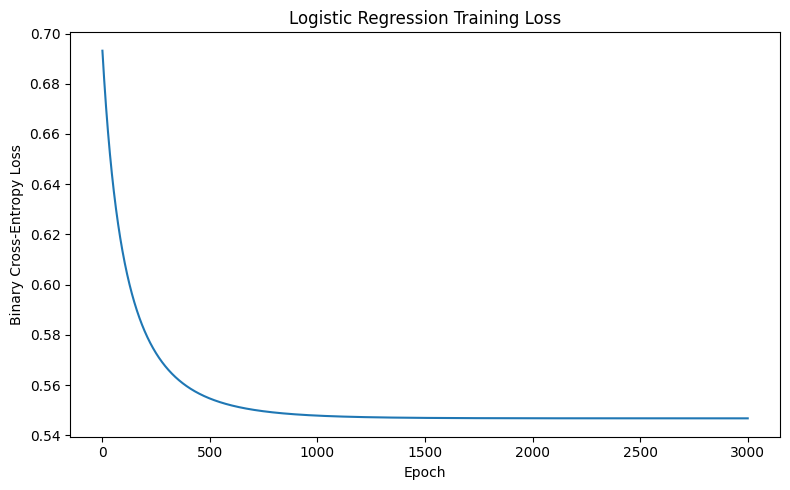

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(logreg_loss_history) + 1),
    logreg_loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Logistic Regression Training Loss")

plt.tight_layout()
plt.show()

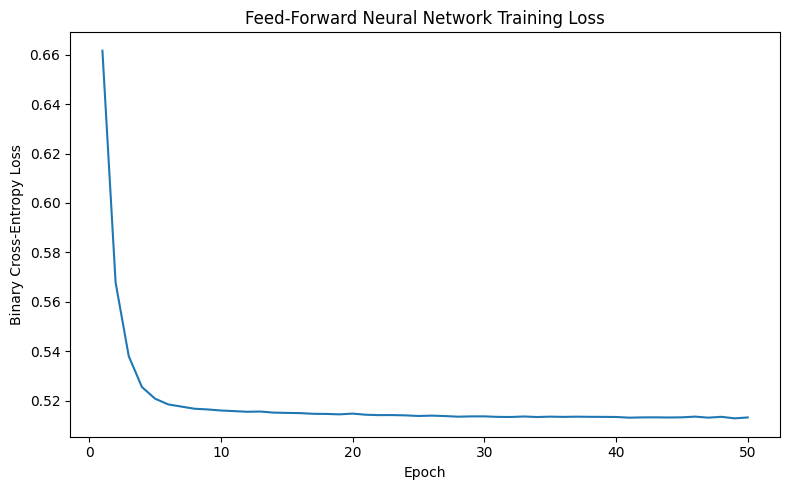

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(ffnn_loss_history) + 1),
    ffnn_loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Feed-Forward Neural Network Training Loss")

plt.tight_layout()
plt.show()

## 9. Results and Discussion

### Logistic Regression

The learned logistic regression parameters on the original feature scale were:

| Feature | Learned Weight |
|---|---:|
| Positive lexicon word count | 0.205613 |
| Negative lexicon word count | -0.169755 |
| Presence of "no" | -0.608538 |
| Pronoun count | -0.027845 |
| Presence of "!" | -0.045519 |
| Log document length | 0.040702 |
| Bias | -0.277874 |

Therefore, the trained logistic regression model is:

\[
z =
0.205613x_1
-0.169755x_2
-0.608538x_3
-0.027845x_4
-0.045519x_5
+0.040702x_6
-0.277874
\]

and:

\[
P(y=1 \mid \mathbf{x})
=
\frac{1}{1+e^{-z}}
\]

The signs of the learned parameters are generally intuitive. Positive sentiment words have a positive coefficient, increasing the predicted probability of positive sentiment. Negative words have a negative coefficient, decreasing the probability. The presence of the word "no" also has a relatively strong negative effect.

The remaining features have smaller coefficients, suggesting that pronoun usage, exclamation marks, and document length provide less direct discriminative information than positive and negative word counts.

### Model Performance

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| Logistic Regression | 0.7386 | 0.7397 | 0.7361 | 0.7379 |
| Feed-Forward Neural Network | 0.7419 | 0.7539 | 0.7182 | 0.7356 |

The feed-forward neural network achieved the highest overall accuracy at 74.19%, compared with 73.86% for logistic regression. It also produced higher precision, meaning that its positive predictions were somewhat more reliable.

However, logistic regression achieved higher recall and a slightly higher F1 score. Therefore, the neural network did not produce a large overall improvement.

This result is reasonable because each entire movie review was reduced to only six manually engineered features. Although the feed-forward neural network can model nonlinear relationships among those features, much of the original language information—such as word order, context, syntax, and detailed vocabulary—is no longer available to either model.

The results therefore demonstrate an important principle: increasing model complexity does not automatically produce substantially better performance when the input representation contains limited information.

## 10. Why the Implementation Finds the Weights

The logistic regression implementation follows the mathematical optimization procedure directly.

1. The six input features are multiplied by their corresponding weights and combined with the bias to produce the linear score \(z\).

2. The sigmoid function converts this score into a probability between 0 and 1.

3. Binary cross-entropy measures the difference between the predicted probability and the known sentiment label.

4. The gradients of the loss with respect to each weight and the bias are calculated.

5. Gradient descent updates the parameters in the direction opposite to the gradient:

\[
w_j \leftarrow
w_j-\eta\frac{\partial L}{\partial w_j}
\]

6. This process is repeated for many epochs. As training proceeds, the loss decreases and the parameters move toward values that better explain the labeled training examples.

Because binary logistic regression with cross-entropy loss is a convex optimization problem, gradient descent can reach the global minimum under appropriate optimization conditions.

The feed-forward neural network follows the same general learning principle but contains multiple layers of weights. PyTorch automatically computes the necessary gradients through backpropagation using `loss.backward()`, while the optimizer updates the parameters using `optimizer.step()`.

The use of `BCEWithLogitsLoss` is appropriate for binary classification because it combines the sigmoid transformation and binary cross-entropy calculation in a numerically stable operation.

## 11. Logistic Regression Pseudocode

```text
INPUT:
    Training feature matrix X
    Training labels y
    Learning rate η
    Number of epochs

INITIALIZE:
    weights W = zeros
    bias B = 0

FOR each training epoch:

    z = XW + B

    predictions = sigmoid(z)

    loss = binary_cross_entropy(y, predictions)

    error = predictions - y

    gradient_W = transpose(X) × error / number_of_samples

    gradient_B = mean(error)

    W = W - η × gradient_W

    B = B - η × gradient_B

RETURN:
    optimized W and B

## 13. Classification of a New Review

The following new review was not part of the training or testing datasets:

> "I loved this movie! The story was wonderful and the performances were excellent. I really enjoyed watching it and I would definitely recommend it to you."

The feature extraction process produced:

| Feature | Value |
|---|---:|
| Positive lexicon count | 5 |
| Negative lexicon count | 0 |
| Contains "no" | 0 |
| Pronoun count | 4 |
| Contains "!" | 1 |
| Log word count | 3.2581 |

After applying the training-set standardization:

- Logistic Regression positive probability = **0.673905**
- Feed-Forward Neural Network positive probability = **0.945082**

Because both probabilities are greater than the classification threshold of 0.5, both models classify the review as:

**Positive sentiment**

This example demonstrates the complete inference process:

\[
\text{Raw text}
\rightarrow
\text{Six sentiment features}
\rightarrow
\text{Model}
\rightarrow
\text{Probability}
\rightarrow
\text{Sentiment class}
\]

## 14. Conclusion

This project demonstrated sentiment classification using logistic regression and a feed-forward neural network trained on the IMDb Large Movie Review Dataset.

Each movie review was transformed into six interpretable sentiment features rather than using the complete vocabulary of the document. Logistic regression learned six weights and one bias through binary cross-entropy minimization and gradient descent. The learned parameters were consistent with intuitive sentiment relationships: positive words increased positive-class probability, while negative words and the presence of "no" reduced it.

The logistic regression model achieved 73.86% test accuracy, while the feed-forward neural network achieved 74.19%. The relatively small difference shows that additional model complexity provides limited improvement when the underlying input representation contains only six features.

The experiment also demonstrated the learning process directly. After one backpropagation update, the probability assigned to the correct class increased and the loss decreased. Finally, both trained models correctly classified a new positive movie review.

Overall, the project illustrates the relationship between feature engineering, logistic regression, neural networks, gradient-based learning, and binary text classification.

## References

Maas, A. L., Daly, R. E., Pham, P. T., Huang, D., Ng, A. Y., & Potts, C. (2011). Learning word vectors for sentiment analysis. *Proceedings of the 49th Annual Meeting of the Association for Computational Linguistics: Human Language Technologies*, 142–150. Association for Computational Linguistics.

NLTK Project. (2025). *Opinion Lexicon Corpus Reader*. Natural Language Toolkit documentation.

PyTorch. (2026). *BCEWithLogitsLoss*. PyTorch documentation.

## AI Use Disclosure

OpenAI ChatGPT was used as a learning and development aid during this project. It was used to help explain logistic regression, gradient descent, feed-forward neural networks, backpropagation, organize the project structure, and review Python implementation logic.

All code was executed locally using the specified IMDb dataset, and numerical results—including learned weights, model performance metrics, training-loss values, and classification probabilities—were generated and verified through actual program execution. The final results were reviewed against the mathematical equations and observed program output. The author remains responsible for the accuracy, interpretation, and integrity of the submitted work.